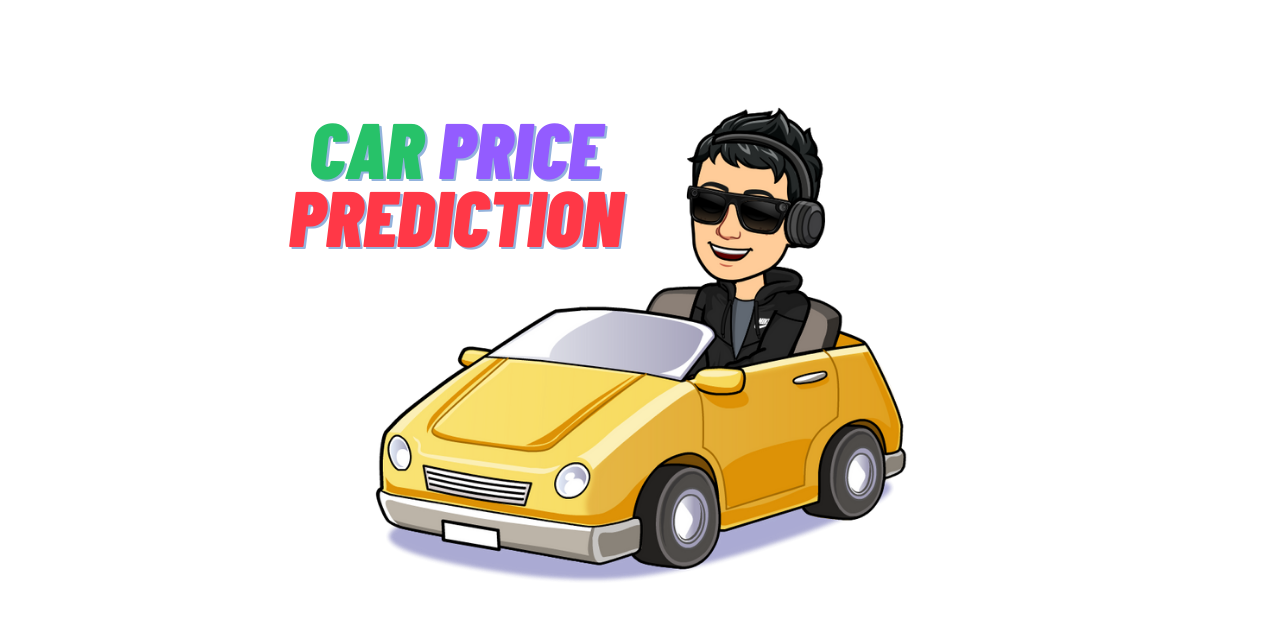

# EDA Project: car price prediction


## **What is this project about?**
**Car Price Prediction**

This EDA is for the Car Price Prediction project.
The goal of this project is to analyze car features and predict their prices using machine learning techniques.

Dataset contains information about different cars and their specifications.
Target variable: Price

**Why EDA?**

- To understand the data structure

- To detect patterns and outliers

- To extract meaningful insights before modeling


| Column           | Meaning                           | Why is it important?                                 |
| ---------------- | --------------------------------- | ---------------------------------------------------- |
| ID               | Unique identifier for each car    | Not useful for prediction, used for indexing only    |
| Price            | Price of the car                  | **Target variable** we aim to predict                |
| Levy             | Additional tax or fee             | Can affect the final price of the car                |
| Manufacturer     | Car manufacturer (brand)          | Different brands have different price ranges         |
| Model            | Car model name                    | Models strongly influence price                      |
| Prod. year       | Year the car was produced         | Newer cars usually have higher prices                |
| Category         | Type of the car                   | Different categories have different pricing patterns |
| Leather interior | Whether the car has leather seats | Luxury feature that may increase price               |
| Fuel type        | Type of fuel used                 | Affects performance and market value                 |
| Engine volume    | Engine size                       | Larger engines often correlate with higher prices    |
| Mileage          | Distance traveled by the car      | Higher mileage usually reduces price                 |
| Cylinders        | Number of engine cylinders        | Indicates engine power and performance               |
| Gear box type    | Transmission type                 | Automatic cars may differ in price from manual       |
| Drive wheels     | Type of drive system              | Impacts performance and pricing                      |
| Doors            | Number of doors                   | Can reflect car type and usage                       |
| Wheel            | Steering wheel position           | May affect market depending on region                |
| Color            | Color of the car                  | Sometimes influences buyer preference                |
| Airbags          | Number of airbags                 | Safety feature that can affect price                 |
| Random_notes     | Additional notes                  | Usually not useful for modeling                      |


# Exploration

In [93]:
pip install pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [173]:
pip install jinja2 pillow

Note: you may need to restart the kernel to use updated packages.


In [95]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# to read data

In [96]:
#Load the dataset 
df = pd.read_csv("../car data/train_car_price.csv")


**Check if the dataset was loaded successfully**

In [97]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN


# 1) Data Understanding 

In [98]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,15789.0,4.557887e+07,934719.703416,20746880.0,45708484.0,45772520.0,45802047.0,45816651.0
Prod. year,15789.0,2.010917e+03,5.699507,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,15789.0,4.582431e+00,1.198396,1.0,4.0,4.0,4.0,16.0
Airbags,15789.0,6.560580e+00,4.315139,0.0,4.0,6.0,12.0,16.0
Random_notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15789 entries, 0 to 15788
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                15789 non-null  int64  
 1   Price             15789 non-null  str    
 2   Levy              14421 non-null  str    
 3   Manufacturer      15789 non-null  str    
 4   Model             15789 non-null  str    
 5   Prod. year        15789 non-null  int64  
 6   Category          15789 non-null  str    
 7   Leather interior  15789 non-null  str    
 8   Fuel type         15789 non-null  str    
 9   Engine volume     15789 non-null  str    
 10  Mileage           14421 non-null  str    
 11  Cylinders         15789 non-null  float64
 12  Gear box type     15789 non-null  str    
 13  Drive wheels      15789 non-null  str    
 14  Doors             15789 non-null  str    
 15  Wheel             15789 non-null  str    
 16  Color             14421 non-null  str    
 17  Airb

In [100]:
df.describe()

,ID,Prod. year,Cylinders,Airbags,Random_notes
count,1.578900e+04,15789.000000,15789.000000,15789.000000,0.0
mean,4.557887e+07,2010.917031,4.582431,6.560580,NaN
std,9.347197e+05,5.699507,1.198396,4.315139,NaN
min,2.074688e+07,1939.000000,1.000000,0.000000,NaN
25%,4.570848e+07,2009.000000,4.000000,4.000000,NaN
50%,4.577252e+07,2012.000000,4.000000,6.000000,NaN
75%,4.580205e+07,2015.000000,4.000000,12.000000,NaN
max,4.581665e+07,2020.000000,16.000000,16.000000,NaN


In [101]:
#Inspect shape, columns, data types
print( " Data shape:" , df.shape)
print("\n Column names: \n", df.columns)
print("\nData types:\n", df.dtypes)

 Data shape: (15789, 19)

 Column names: 
 Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags', 'Random_notes'],
      dtype='str')

Data types:
 ID                    int64
Price                   str
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
Random_notes        float64
dtype: object


**Check missing**

In [102]:
#Identify missing values
print("\nMissing values in each column:\n", df.isnull().sum())




Missing values in each column:
 ID                      0
Price                   0
Levy                 1368
Manufacturer            0
Model                   0
Prod. year              0
Category                0
Leather interior        0
Fuel type               0
Engine volume           0
Mileage              1368
Cylinders               0
Gear box type           0
Drive wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64


In [103]:
# all missing
df.isna().sum().sum()

np.int64(19893)

# Key Observations:
*  15789 rows, 19 columns
* We note that several important numerical features such as color, Levy, Mileage, Engine volume, and Prod. year are stored as strings, which indicates incorrect data types and the need for conversion before performing calculations.
* The target variable Price is not in numeric format and must be cleaned and converted to a numerical type.
* There are missing values in Levy, Mileage, and Color (1368 missing values each).
* The column Random_notes is empty so we will drop.
* cylinders  always = 4 

# **Type casting**

In [104]:
# remove space from col num
df.columns = df.columns.str.replace(' ', '_')

df.columns


Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod._year',
       'Category', 'Leather_interior', 'Fuel_type', 'Engine_volume', 'Mileage',
       'Cylinders', 'Gear_box_type', 'Drive_wheels', 'Doors', 'Wheel', 'Color',
       'Airbags', 'Random_notes'],
      dtype='str')

In [105]:
print("\nData types:\n", df.dtypes)


Data types:
 ID                    int64
Price                   str
Levy                    str
Manufacturer            str
Model                   str
Prod._year            int64
Category                str
Leather_interior        str
Fuel_type               str
Engine_volume           str
Mileage                 str
Cylinders           float64
Gear_box_type           str
Drive_wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
Random_notes        float64
dtype: object


In [106]:
#Drop ID
df.drop('ID', axis=1, inplace=True)

In [107]:
# price (str to num)

df['Price'] = df['Price'].str.split('-').str[0]
df['Price'] = df['Price'].str.replace('₹','').str.replace('$','')
df['Price'] = df['Price'].str.replace(',','')
df['Price']
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [108]:
# proud._year (str to num)
df['Prod._year'] 
df['Prod._year'] = pd.to_numeric(df['Prod._year'], errors='coerce')

In [109]:
# Engine_volume(str to num)
df['Engine_volume'] = df['Engine_volume'].str.extract(r'(\d+\.?\d*)')
df['Engine_volume']
df['Engine_volume'] = pd.to_numeric(df['Engine_volume'], errors='coerce')

In [110]:
# Doors
df['Doors'] = df['Doors'].str.extract(r'(\d+)')
df['Doors'] = pd.to_numeric(df['Doors'], errors='coerce')


In [111]:
#  missing
df.isnull().sum()

Price                   0
Levy                 1368
Manufacturer            0
Model                   0
Prod._year              0
Category                0
Leather_interior        0
Fuel_type               0
Engine_volume           0
Mileage              1368
Cylinders               0
Gear_box_type           0
Drive_wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64

# 2)Data Cleaning

 **A) Removing and fill Missing**

In [112]:
# drop Random_notes 
df.drop('Random_notes', axis=1, inplace=True)

df.shape


(15789, 17)

In [113]:
# Filling missing values in levy
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')
df['Levy'] = df['Levy'].fillna(df['Levy'].median())


In [114]:
# Filling missing values in Mileage

df['Mileage'] = df['Mileage'].str.replace('KM', '')

df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Mileage'].head(10)
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].median())

In [115]:
# Filling missing values in Color (categorical)
df['Color'] = df['Color'].replace(['', ' ', '-', 'Unknown'], np.nan)
df['Color'] = df['Color'].fillna(df['Color'].mode()[0])

In [116]:
#Feature Engineering
from datetime import datetime

current_year = datetime.now().year

df['Age_of_car'] = current_year - df['Prod._year']
df['Age_of_car']
df['Age_of_car'].isna().sum()

np.int64(0)

In [117]:
# sure there is not missing
df.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Model               0
Prod._year          0
Category            0
Leather_interior    0
Fuel_type           0
Engine_volume       0
Mileage             0
Cylinders           0
Gear_box_type       0
Drive_wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
Age_of_car          0
dtype: int64

**Check Dublicates**

In [118]:
df.duplicated().sum()

np.int64(2573)

**B) Removing duplicates**

In [119]:
df.drop_duplicates(inplace=True)

In [120]:
# check after removing
print( " Data shape before:" , df.shape)
print(df.duplicated().sum())
print("num of col after",df.shape)

 Data shape before: (13216, 18)
0
num of col after (13216, 18)


# Check Outlier

In [121]:
feats = df.select_dtypes(np.number).columns

for feat in feats:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = df[ (df[feat] < lower)  | (df[feat] > upper) ]
    if not mask.empty:
        print(f'{feat} has outlier {len(mask)}')

Price has outlier 784
Levy has outlier 4712
Prod._year has outlier 451
Engine_volume has outlier 614
Mileage has outlier 503
Cylinders has outlier 2952
Doors has outlier 722
Age_of_car has outlier 451


In [122]:
print(df.shape)

for feat in feats:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df[feat] = np.clip(df[feat], lower, upper)

(13216, 18)


**Key Observations:**
- convert data from string to (num)
- clean 4 columns
- find sum of misssing value
- fill it

## EDA

In [123]:
def info(col):
    print("min", df[col].min())
    print("max", df[col].max())
    print("STD", df[col].std())
    print("Skewness", df[col].skew())
    len_unique = len(df[col].value_counts())
    print(f'Unique value counts: {len_unique}')
    if len_unique < 12:
        print(df[col].value_counts())

In [124]:
def group_by(col, fun):
    group_fun = df.groupby(col)["trip_duration"].agg(fun).reset_index()
    return group_fun

## Price Analysis

In [125]:
Y = df.iloc[:, 1]
Y

0        948.5
1        730.0
2        781.0
3        781.0
4        781.0
         ...  
15781    948.5
15782    833.0
15784    880.0
15787    781.0
15788    781.0
Name: Levy, Length: 13216, dtype: float64

In [126]:
info("Price")

min 1
max 47198
STD 13231.358328698981
Skewness 0.8727746953683576
Unique value counts: 1700


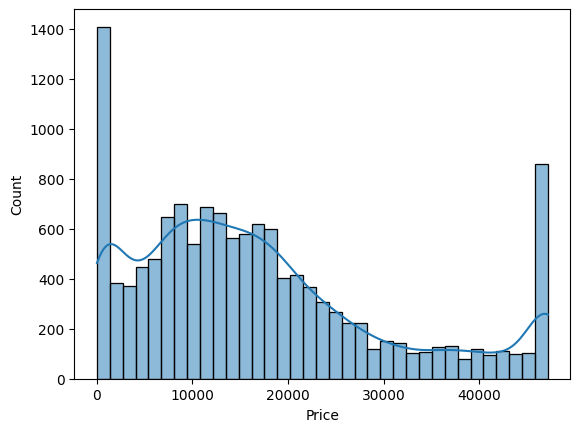

In [127]:
sns.histplot(df['Price'], kde=True)
plt.show()

In [128]:
df['log_Price'] = np.log(df['Price'])
info("log_Price")


min 0.0
max 10.762106797794535
STD 1.4547906342548254
Skewness -1.8894629437688668
Unique value counts: 1700


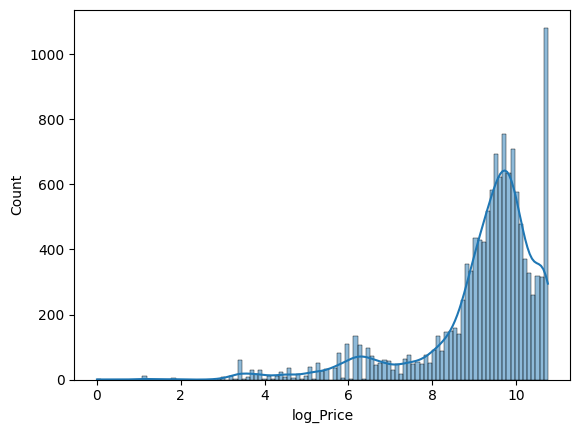

In [129]:
sns.histplot(df['log_Price'], kde=True)
plt.show()

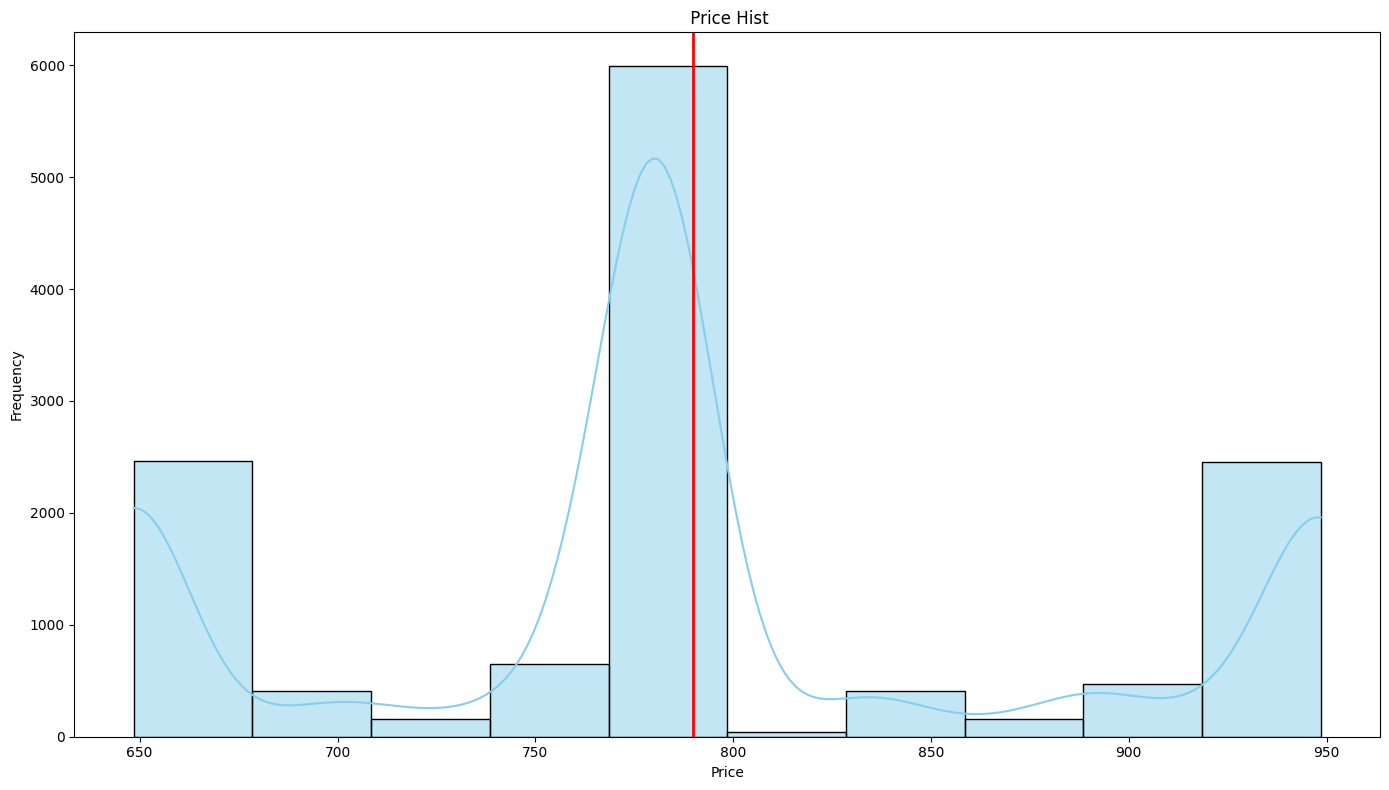

In [130]:
plt.figure(figsize=(14,8))

sns.histplot(Y, kde=True, bins=10, color="skyblue", edgecolor="black")
plt.axvline(Y.mean(), color="red", linewidth=2, label='Mean')


plt.title(" Price Hist")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Conclusion**
-8000:18000 The original Price distribution is right-skewed, indicating that most cars are concentrated in lower price ranges with a few high-priced outliers. After applying a logarithmic transformation, the distribution becomes more normalized and less skewed, which can improve model performance by stabilizing variance and reducing the impact of extreme values.

In [131]:
# The relationship between price and car age
df['Price'].corr(df['Age_of_car'])

np.float64(-0.38745408010633325)

**insights**
- The relationship between price and car age is **inverse (negative)**, meaning that as the age of the car increases, the price decreases, which is reflected by a negative correlation coefficient.


#  Numerical Analysis

In [132]:
# Display numeric features

num_feats = df.select_dtypes(np.number).columns
num_feats

Index(['Price', 'Levy', 'Prod._year', 'Engine_volume', 'Mileage', 'Cylinders',
       'Doors', 'Airbags', 'Age_of_car', 'log_Price'],
      dtype='str')

**Manufacturer analysis**

In [133]:
def group_by(col,fun):
  group_fun=df.groupby(col)["Price"].agg(fun).reset_index()
  return group_fun

In [134]:
info("Engine_volume")

min 0.4999999999999998
max 3.7
STD 0.6641239231554189
Skewness 0.7858506122457523
Unique value counts: 34


In [135]:
mean_Engine_volume_group = group_by('Engine_volume', 'mean')
mean_Engine_volume_group.head(10).sort_values(by="Engine_volume", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['Price'])

,Engine_volume,Price
0,1.300000,8740.871537
1,1.200000,8547.183908
2,1.100000,5563.714286
3,1.000000,10134.216495
4,0.900000,5096.000000
5,0.800000,9068.500000
6,0.700000,7024.166667
7,0.600000,4613.833333
8,0.500000,1300.000000
9,0.500000,7048.384615


In [136]:
info("Mileage")

min 0.0
max 327143.75
STD 81196.30331408243
Skewness 0.5782225902352052
Unique value counts: 5781


In [137]:
mean_Mileage_group = group_by('Mileage', 'mean')
mean_Mileage_group.head(10).sort_values(by="Mileage", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['Price'])


,Mileage,Price
0,500.000000,11351.200000
1,498.000000,9408.000000
2,429.000000,12701.000000
3,261.000000,3293.000000
4,120.000000,300.000000
5,102.000000,47198.000000
6,21.000000,47198.000000
7,18.000000,135.000000
8,13.000000,17562.000000
9,0.000000,8949.901261


C:\Users\Shaltout Store\AppData\Local\Temp\ipykernel_17180\1565374568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


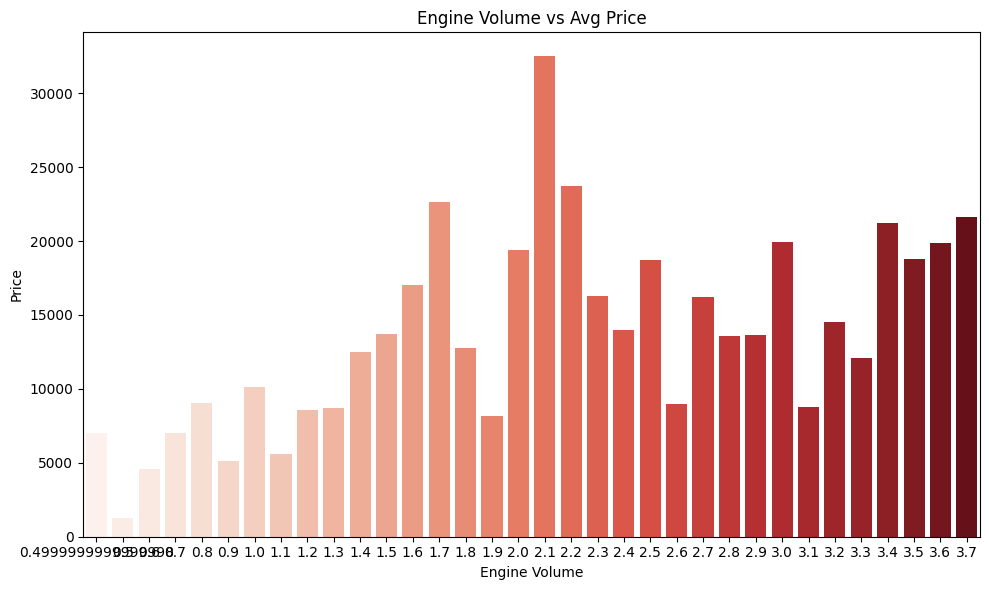

In [138]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mean_Engine_volume_group,
    x="Engine_volume",
    y="Price",
    palette="Reds"
)

plt.title("Engine Volume vs Avg Price")
plt.xlabel("Engine Volume")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

C:\Users\Shaltout Store\AppData\Local\Temp\ipykernel_17180\2517858910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


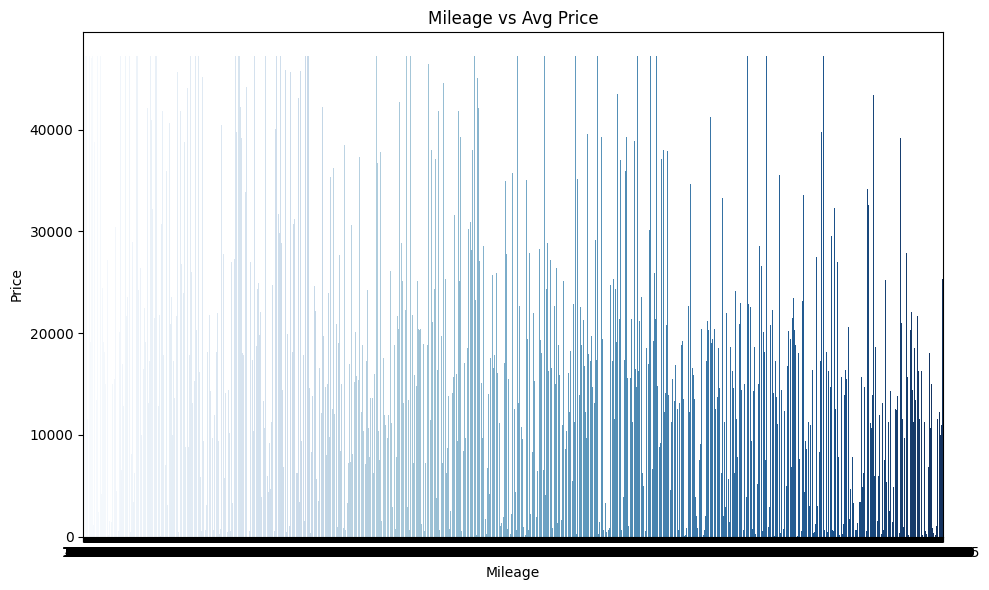

In [139]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mean_Mileage_group,
    x="Mileage",
    y="Price",
    palette="Blues"
)

plt.title("Mileage vs Avg Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

C:\Users\Shaltout Store\AppData\Local\Temp\ipykernel_17180\2474935916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Shaltout Store\AppData\Local\Temp\ipykernel_17180\2474935916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


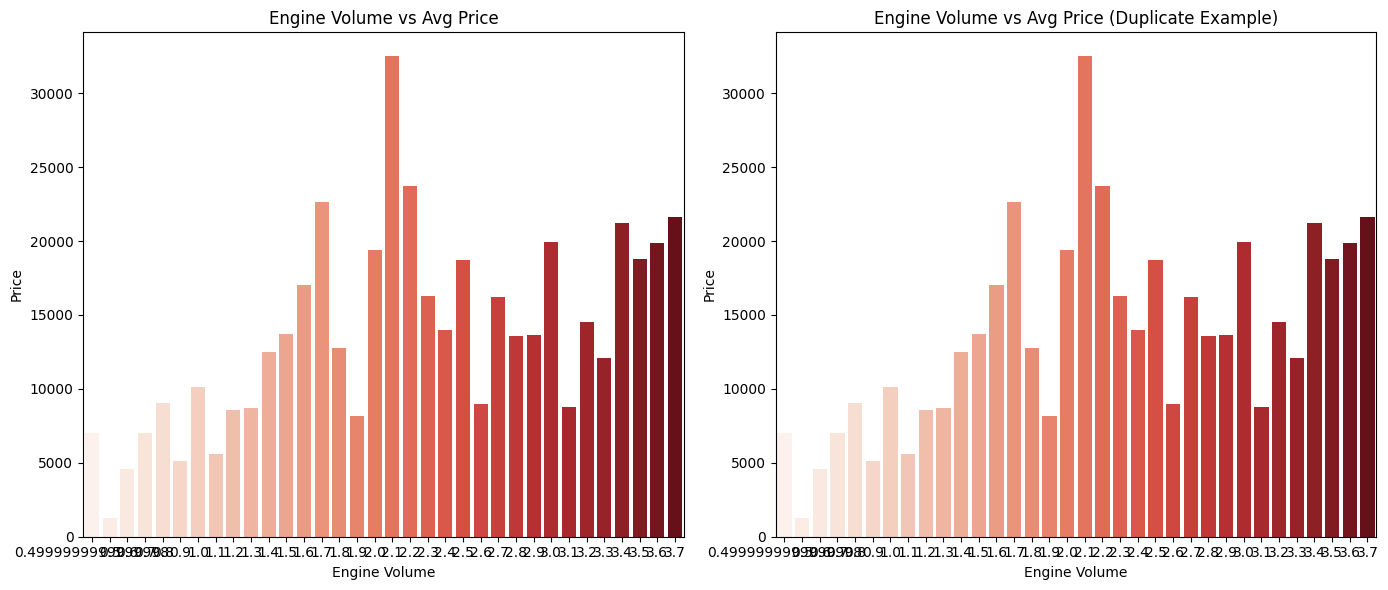

In [140]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(
    data=mean_Engine_volume_group, 
    x="Engine_volume", 
    y="Price", 
    palette="Reds", 
    ax=axes[0]
)
axes[0].set_title("Engine Volume vs Avg Price")
axes[0].set_xlabel("Engine Volume")
axes[0].set_ylabel("Price")

sns.barplot(
    data=mean_Engine_volume_group, 
    x="Engine_volume", 
    y="Price", 
    palette="Reds", 
    ax=axes[1]
)
axes[1].set_title("Engine Volume vs Avg Price (Duplicate Example)")
axes[1].set_xlabel("Engine Volume")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

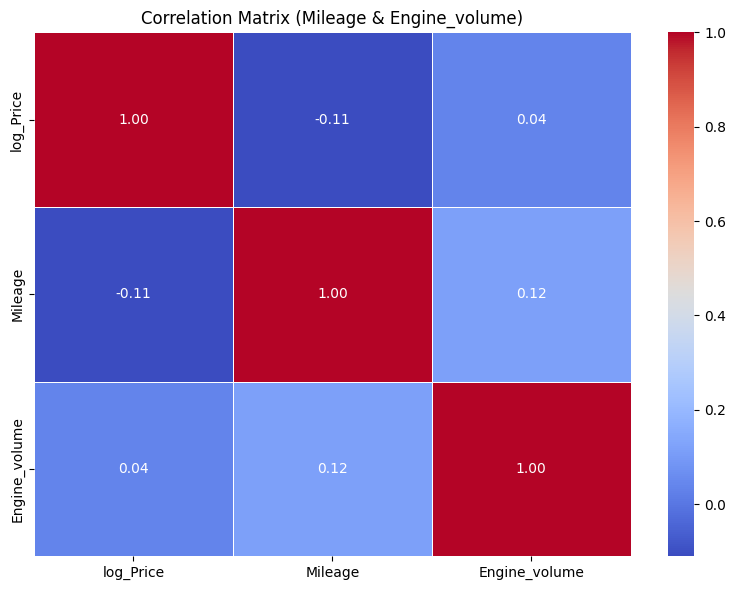

In [141]:
feats = df[[
    "log_Price",
    "Mileage",
    "Engine_volume"
]]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix (Mileage & Engine_volume)")
plt.tight_layout()
plt.show()

## Longitude & Latitude analysis

In [142]:
feats = ["Mileage", "Engine_volume", "Cylinders", "Age_of_car"]

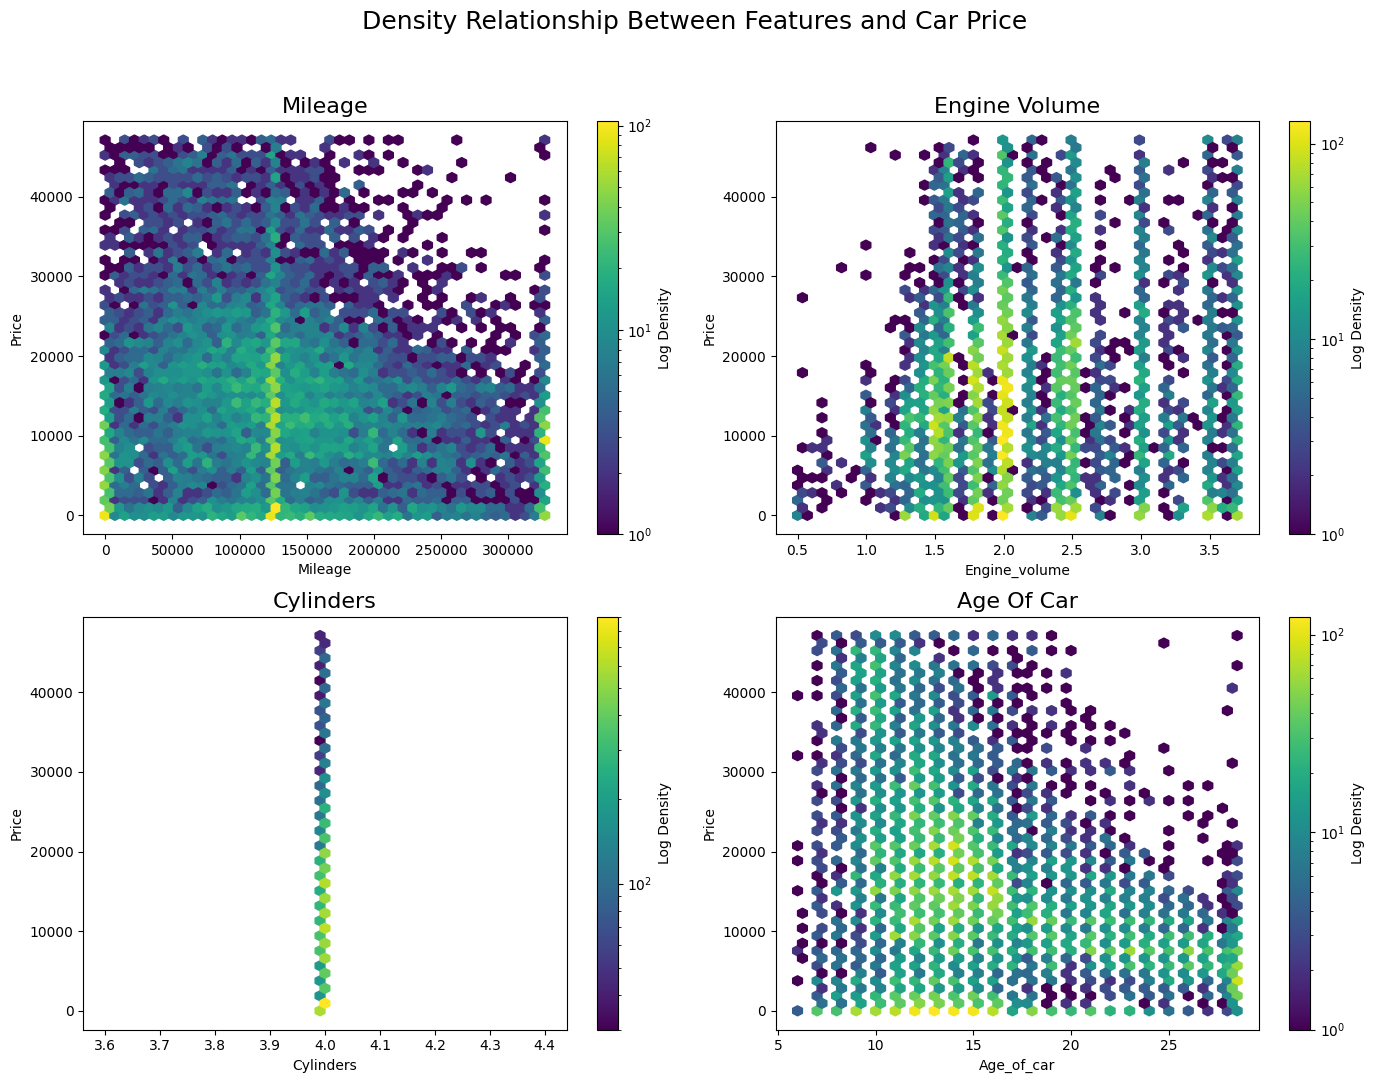

In [143]:
y = df['Price']
y_clip = y[y < y.quantile(0.99)]

plt.figure(figsize=(14,11))

for i in range(4):
    ax = plt.subplot(2,2, i+1)
    
    hb = ax.hexbin(
        df.loc[y_clip.index, feats[i]],
        y_clip,
        gridsize=45,
        bins='log',
        mincnt=1
    )

    ax.set_title(feats[i].replace('_', " ").title(), fontsize=16)
    ax.set_xlabel(feats[i])
    ax.set_ylabel('Price')

    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Log Density')

plt.suptitle('Density Relationship Between Features and Car Price', fontsize=18)

plt.tight_layout(rect=[0,0, 1, 0.95])
plt.show()

**insights**
1) Mileage

- There’s a clear negative relationship: as mileage increases → price generally decreases.
- Low-mileage cars show a wide price range (both cheap and expensive), but high-mileage cars cluster at lower prices.
- Highest density appears around ~80k–150k mileage with mid-range prices.

2) Engine Volume

- A moderately positive relationship: larger engine volume → higher prices.
- Most cars are concentrated around 2.0–2.5L, with strong density in mid-price ranges.
- Smaller engines (<1.5L) tend to be cheaper, while larger ones (>3.0L) are often more expensive.


3) Age of Car

- Strong negative relationship: older cars → lower prices.
- Newer cars (around 6–12 years old) tend to have higher and more varied prices.
- After ~20 years, most prices drop significantly.

In [144]:
for feat in feats:
    print('-'*10, feat, '-'*10)
    info(feat)

---------- Mileage ----------
min 0.0
max 327143.75
STD 81196.30331408243
Skewness 0.5782225902352052
Unique value counts: 5781
---------- Engine_volume ----------
min 0.4999999999999998
max 3.7
STD 0.6641239231554189
Skewness 0.7858506122457523
Unique value counts: 34
---------- Cylinders ----------
min 4.0
max 4.0
STD 0.0
Skewness 0.0
Unique value counts: 1
Cylinders
4.0    13216
Name: count, dtype: int64
---------- Age_of_car ----------
min 6.0
max 28.5
STD 5.3591897840529175
Skewness 0.9316926267209928
Unique value counts: 24


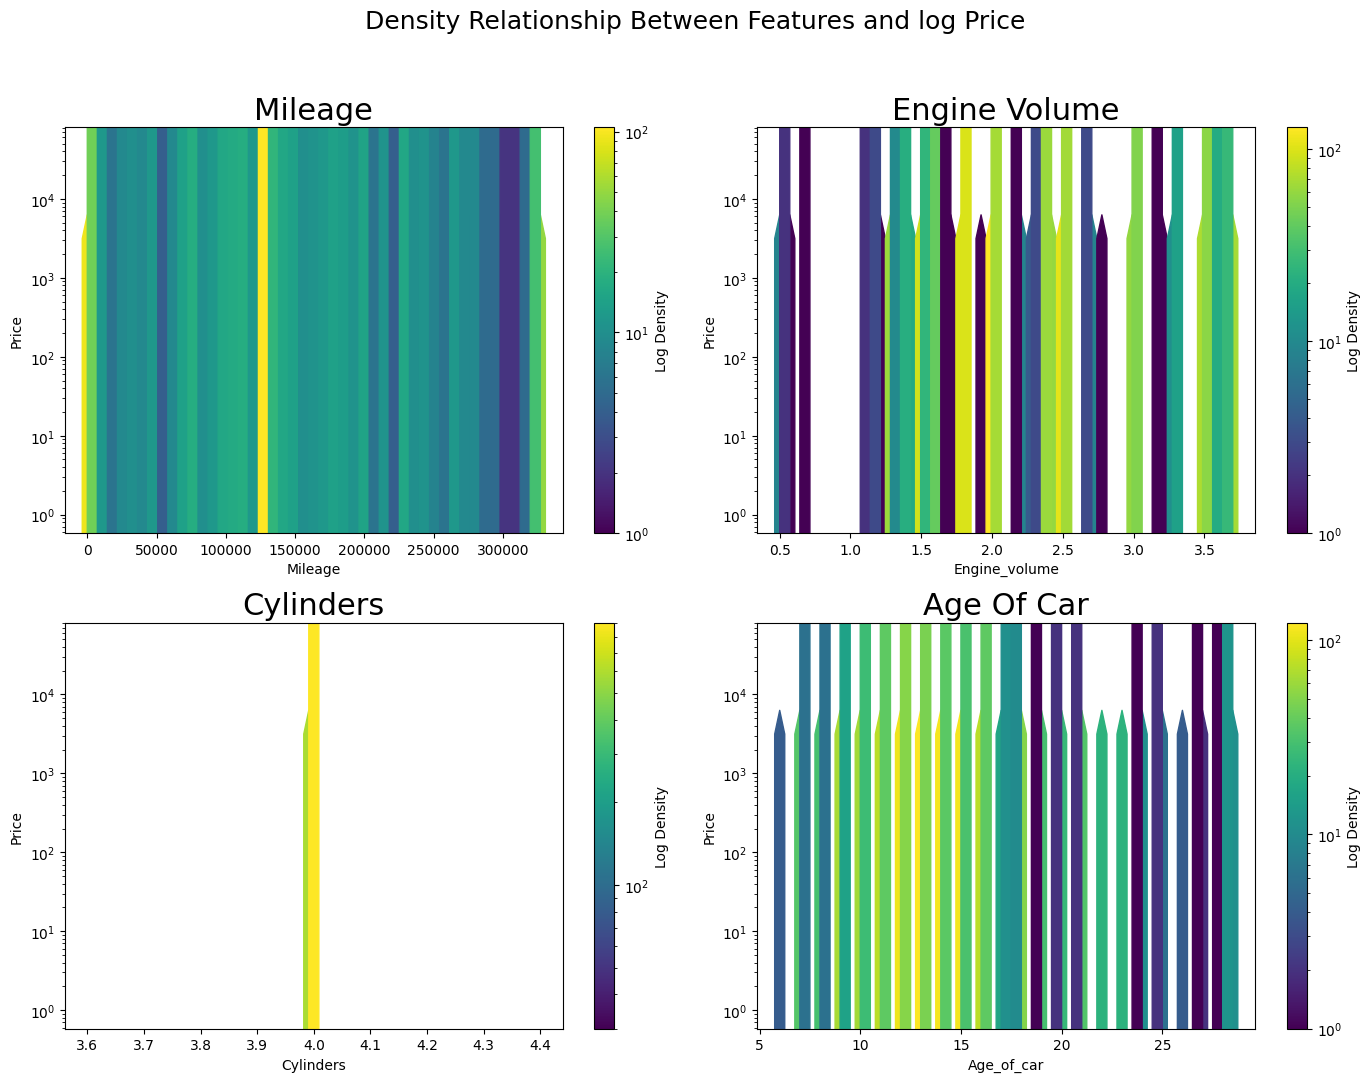

In [145]:
y = df['Price']
y_clip = y[y < y.quantile(0.99)]

plt.figure(figsize=(14,11))

for i in range(4):
    ax = plt.subplot(2,2, i+1)
    hb = ax.hexbin(
        df.loc[y_clip.index, feats[i]],
        y_clip,  
        gridsize=45,
        bins='log',
        mincnt=1
    )

    ax.set_title(feats[i].replace('_', " ").title(), fontsize=22)
    ax.set_xlabel(feats[i])
    ax.set_ylabel('Price')
    ax.set_yscale('log')

    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Log Density')


plt.suptitle('Density Relationship Between Features and log Price', fontsize=18)

plt.tight_layout(rect=[0,0, 1, 0.95])
plt.show()

In [146]:
# Price per Mileage
df['price_per_km'] = df['Price'] / df['Mileage']

In [147]:
# Engine Power Ratio
df['engine_per_cylinder'] = df['Engine_volume'] / df['Cylinders']

In [148]:
# إزالة outliers 
df_clean = df[
    (df['Mileage'] < df['Mileage'].quantile(0.99)) &
    (df['Age_of_car'] < df['Age_of_car'].quantile(0.99))
]

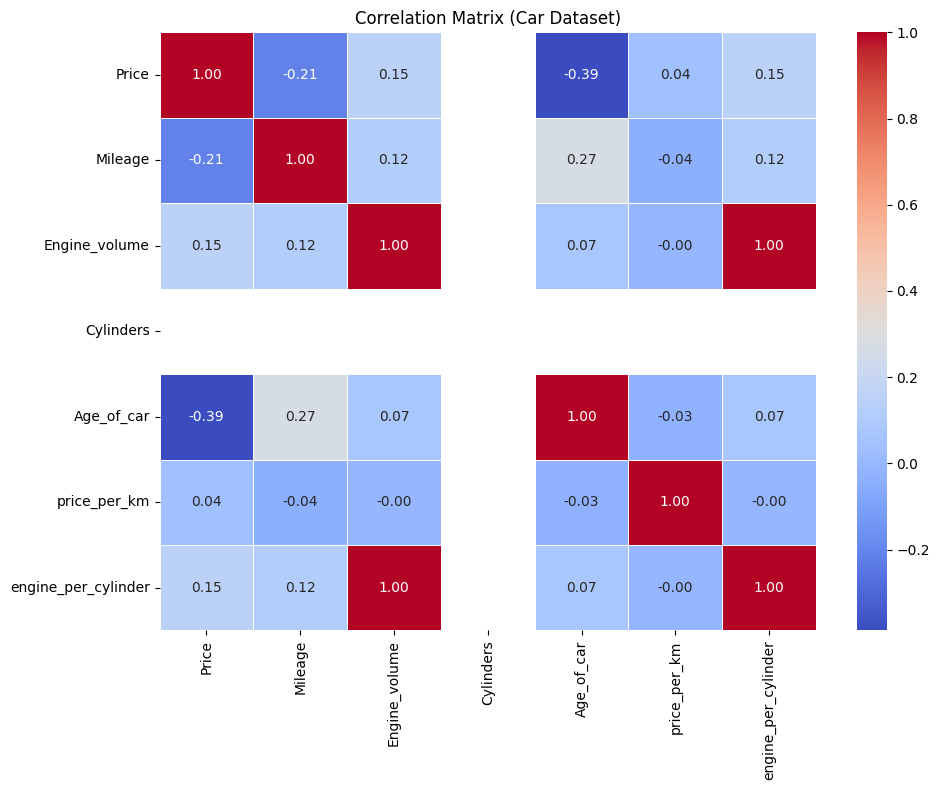

In [149]:
matrix = df[[
    "Price",
    "Mileage",
    "Engine_volume",
    "Cylinders",
    "Age_of_car",
    "price_per_km",
    "engine_per_cylinder"
]]
matrix = matrix.dropna()
corr_matrix = matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt='.2f', 
    linewidths=0.5
)
plt.title("Correlation Matrix (Car Dataset)")
plt.tight_layout()
plt.show()


**insighs**
- Age of the car has the strongest effect. Older cars are cheaper
Mileage also lowers price but less than age

Other features have very weak impact

Engine per cylinder is basically the same as engine volume

Final takeaway
Price mainly depends on age and mileage

**Categorical Analysis**

Leather_interior

In [150]:
from sklearn.preprocessing import LabelEncoder

In [151]:
df['Leather_interior']

0        Yes
1        Yes
2        Yes
3         No
4         No
        ... 
15781    Yes
15782    Yes
15784    Yes
15787    Yes
15788     No
Name: Leather_interior, Length: 13216, dtype: str

In [152]:

feat = 'Leather_interior'

le = LabelEncoder()
df[feat] = le.fit_transform(df[feat])

df[feat].head()

0    1
1    1
2    1
3    0
4    0
Name: Leather_interior, dtype: int64

In [153]:
info('Leather_interior')

min 0
max 1
STD 0.4654596361878308
Skewness -0.7849661574262794
Unique value counts: 2
Leather_interior
1    9022
0    4194
Name: count, dtype: int64


In [154]:
df['Leather_interior'].value_counts()

Leather_interior
1    9022
0    4194
Name: count, dtype: int64

In [155]:
mean_Leather_interior_group = group_by('Leather_interior', 'mean')
mean_Leather_interior_group.head(10).sort_values(by="Leather_interior", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['Price'])


,Leather_interior,Price
0,1,18640.744070
1,0,13264.690749


In [156]:
from sklearn.preprocessing import LabelEncoder
feat = 'Fuel_type'
le = LabelEncoder()
df[feat] = le.fit_transform(df[feat])
df[feat].head()
info('Fuel_type')

min 0
max 5
STD 1.3458738363817966
Skewness -0.6103376549421072
Unique value counts: 6
Fuel_type
4    7328
1    2729
2    2095
3     615
0     384
5      65
Name: count, dtype: int64


In [157]:
mean_Fuel_type_group = group_by('Fuel_type', 'mean')
mean_Fuel_type_group.head(10).sort_values(by="Fuel_type", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['Price'])

,Fuel_type,Price
0,5,23304.169231
1,4,16063.866266
2,3,13220.821138
3,2,13347.900239
4,1,23951.519238
5,0,8124.403646


In [158]:
from sklearn.preprocessing import LabelEncoder

feat = 'Manufacturer'

le = LabelEncoder()
df[feat] = le.fit_transform(df[feat])

df[feat].head()

0    28
1    23
2    21
3    59
4    35
Name: Manufacturer, dtype: int64

In [159]:
mean_Manufacturer_group = group_by('Manufacturer', 'mean')
mean_Manufacturer_group.head(10).sort_values(by="Manufacturer", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['Price'])

,Manufacturer,Price
0,9,9542.761905
1,8,15533.210327
2,7,12088.181818
3,6,10059.615385
4,5,18838.762646
5,4,47198.000000
6,3,15510.812121
7,2,47198.000000
8,1,4100.000000
9,0,6549.615385


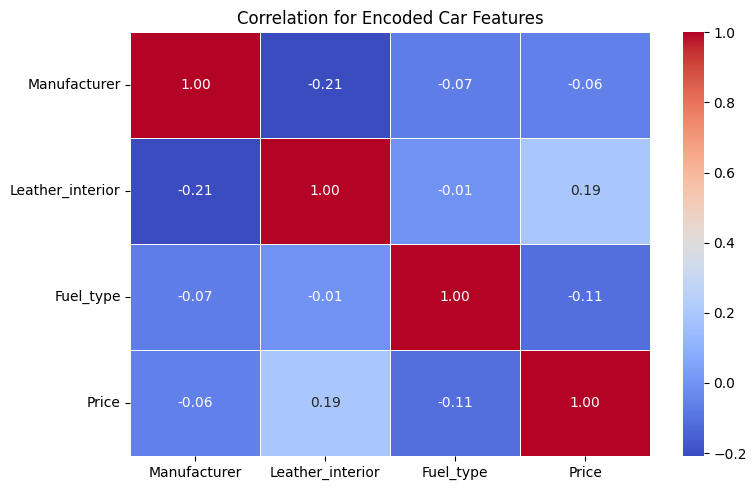

In [160]:
car_features = ['Manufacturer', 'Leather_interior', 'Fuel_type', 'Price']
car_df = df[car_features]
corr_matrix = car_df.corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation for Encoded Car Features')
plt.tight_layout()
plt.show()

In [161]:
from sklearn.preprocessing import LabelEncoder
car_cols = ['Category', 'Gear_box_type', 'Drive_wheels', 'Color', 'Wheel']
le = LabelEncoder()
for col in car_cols:
    df[col] = le.fit_transform(df[col])
df[car_cols].head()

,Category,Gear_box_type,Drive_wheels,Color,Wheel
0,9,0,1,1,0
1,9,0,1,12,0
2,9,0,1,1,0
3,10,1,1,1,0
4,9,1,2,1,0


In [162]:
car_features = ['Manufacturer', 'Leather_interior', 'Fuel_type',
                'Category', 'Gear_box_type', 'Drive_wheels', 'Color', 'Wheel', 'Price']
car_df = df[car_features]
corr_matrix = car_df.corr()

target_corr = corr_matrix['Price'].reset_index().sort_values(by='Price', ascending=False)
print(target_corr.head(7), end='\n\n')
print(target_corr.tail(6))

              index     Price
8             Price  1.000000
1  Leather_interior  0.189122
4     Gear_box_type  0.090597
6             Color -0.012357
5      Drive_wheels -0.038435
0      Manufacturer -0.061177
3          Category -0.086138

          index     Price
6         Color -0.012357
5  Drive_wheels -0.038435
0  Manufacturer -0.061177
3      Category -0.086138
2     Fuel_type -0.111280
7         Wheel -0.189543


# Conclusion
- Original dataset contains 13 main features + Price.
- Drop useless features (e.g., ID, Cylinders – no variation).
- Data are clean: no missing values & no duplicates.
- Target = Price

**Numeric Features:**

- Age of car has the strongest negative correlation with Price.
- Mileage also lowers price, moderate effect.
- Engine volume has minor effect; cylinders irrelevant.
- Derived features (price_per_km, engine_per_cylinder) confirm above.

**Categorical Features:**

- Leather_interior slightly increases price (+0.19 correlation).
- Fuel_type, Manufacturer, Gear_box_type, Drive_wheels, Color, Wheel → weak correlation with Price.

**Top 5 features correlated with Price:**

- Age_of_car
- Mileage
- Leather_interior
- Engine_volume
- Fuel_type


